<a href="https://colab.research.google.com/github/amanmeka/DataScience/blob/main/Unit6/Unit6ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 6 Exercises: Is my model good?

#### Over and Under fitting, Model Visualization, and Model/Variable Selection Concepts

These exercises are meant to get you to think about the model and variable selection process, and consider how we determine if a model is "good".

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import pymc as pm
import xarray as xr
import graphviz as gv
import pymc as pm

from scipy.interpolate import PchipInterpolator

In [ ]:
!pip install bambi

In [3]:
import bambi as bmb
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as pltd

**Task1**:

Does elpd_loo mean anything if we only have one model?

No, because elpd_loo is only useful when used in comparison to another model. Because it is a sum of the log probabilities that depend based on the data set.

**Task2**:

Describe overfitting, in the context of this course

Overfitting is when the model that we have fits the current dataset well but does not generalize to new, similar data. This means that there is not enough room to adapt to inherent variation in reality.  

**Task3**:

How do we mitigate overfitting?

The main way of preventing overfitting is to regularize priors. weakly informative priors can help with having a model that overfits.

**Task4**:

How do we mitigate underfitting?

To mitigate underfitting you sort of do the opposite for what you would do for overfitting and reverse it: making your priors more informative. This will help with the model because it will help with making it fit the data better.

**Task5**:

Why would we want more than one predictor in a model?

Having more than one predictor in a model allows us to look at more complex relationships and have a more complex understanding of the factors that influenced that outccome. A single predictor isn't enough to show the variability in the data.

**Task6**:

Can we have too many predictors? How would we know?

Having too many predictors can lead to issues like overfitting and not being able to interpret the model. Similar to Tasks 3 and 4, you should have a healthy amount of predictors so that the model does not over or under fit.

**Task7**:

What is variable selection, and how does it work?

Variable selection is the process of choosing  subset of predictors that are relevant to use in the model. It works by identifying the variables that are the most influential.

**Task8**:

Describe the differences and similarities between the following three models: linear regression with two predictors, one of which is a categorical variable:

- adding the variables in the model, as is standard.
- using that categorical variable as a hierarchy upon the other predictor variable.
- adding the variables, plus the categorical variable's interaction with the other variable.

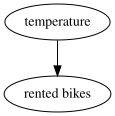

In [4]:
dag_b = gv.Digraph(comment='bikes_dag') #b for bikes

dag_b.node('R', 'rented bikes')
dag_b.node('T','temperature')

dag_b.edges(['TR', ])

dag_b

**Task9**:

How do we visualize multiple linear regression models? Can we visualize the entire model, all at once?

The plot prediction methods in the bambi library, which can create multiple regressions on one graph, can be used. It will create a linear regression model but with all of the variables.

**Task10**:

Compare the following linear models that all use the basketball data to predict field goal percentage:

- predictors free throw percentage and position (with position as a categorical predictor)
- predictors free throw percentage and position (with position as a hierarchy)
- predictors free throw percentage and position (with position interacting with frew throw percentage)
- predictors free throw percentage, position, 3 point attempts, and interactions between all three predictors
- predictors free throw percentage, position, 3 point attempts, with an interaction between 3 point attempts and postion.

using ```az.compare()``` and ```az.plot_compare()```, or an equivalent method using LOO (elpd_loo).

You may use the following two code blocks to load and clean the data.

In [5]:
#have to drop incomplete rows, so that bambi will run
bb = pd.read_csv(
    'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/basketball2324.csv'
    ).dropna()

In [6]:
#only look at players who played more than 600 minutes
#which is 20 min per game, for 30 games
bb = bb.query('MP > 600')
#remove players who never missed a free throw
bb = bb.query('`FT%` != 1.0')
#filter out the combo positions. This will make it easier to read the graphs
bb = bb.query("Pos in ['C','PF','SF','SG','PG']")
#gets rid of the annoying '%' sign
bb.rename(columns={"FT%":"FTp","FG%":"FGp"}, inplace=True)

In [ ]:
model_bb1 = bmb.Model("FGp ~ FTp + Pos", data=bb)
idata_bb1 = model_bb1.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

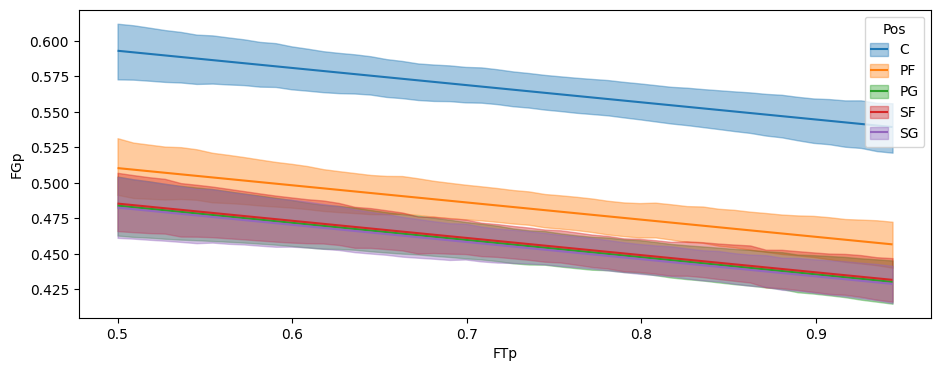

In [8]:
#plot 94% HDIs of the means of each position
bmb.interpret.plot_predictions(model_bb1,
                               idata_bb1,
                                ["FTp",  "Pos"], fig_kwargs={"figsize":(11, 4)})

In [ ]:
model_bb2 = bmb.Model("FGp ~ (FTp|Pos)", data=bb)
idata_bb2 = model_bb2.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

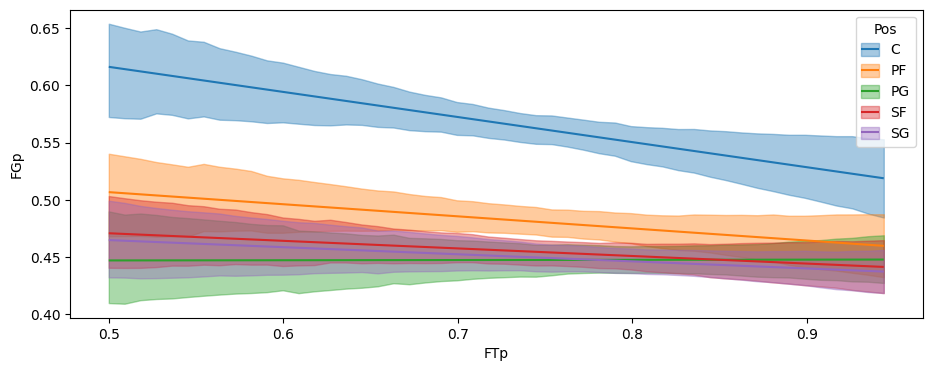

In [10]:
bmb.interpret.plot_predictions(model_bb2,
                               idata_bb2,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [ ]:
model_bb3 = bmb.Model("`FGp` ~ `FTp` + `FTp`:Pos", data=bb)
idata_bb3 = model_bb3.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

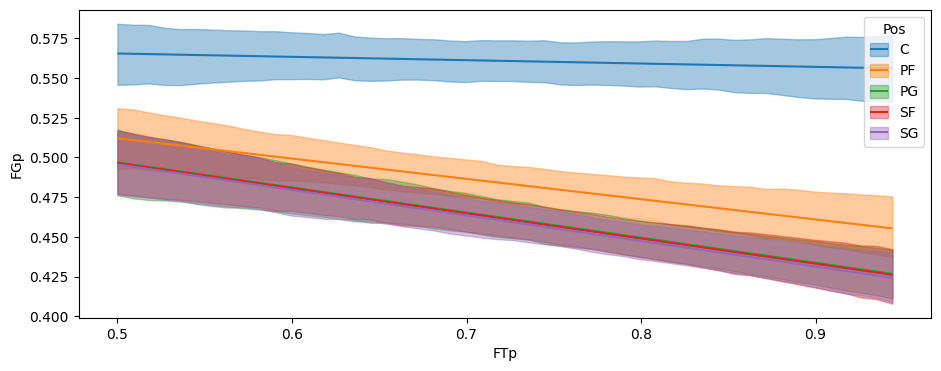

In [12]:
bmb.interpret.plot_predictions(model_bb3,
                               idata_bb3,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

In [ ]:
model_bb4 = bmb.Model("FGp ~ FTp + `3PA` + Pos + Pos:`3PA` + FTp:`3PA`", data=bb)
idata_bb4 = model_bb4.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
bmb.interpret.plot_predictions(model_bb4,
                               idata_bb4,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)}, pps=True)

In [ ]:
model_bb5 = bmb.Model("`FGp` ~ `FTp` + `3PA` + Pos + `3PA`:Pos ", data=bb)
idata_bb5 = model_bb5.fit(idata_kwargs={'log_likelihood': True})

(<Figure size 1100x400 with 1 Axes>,
 array([<Axes: xlabel='FTp', ylabel='FGp'>], dtype=object))

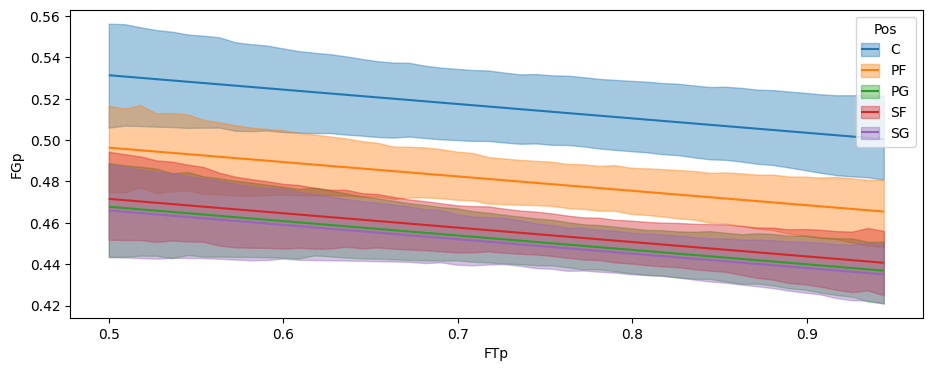

In [16]:
bmb.interpret.plot_predictions(model_bb5,
                               idata_bb5,
                               ["FTp","Pos"],
                               fig_kwargs={"figsize":(11, 4)})

           rank    elpd_loo      p_loo  elpd_diff        weight         se  \
model_4       0  533.167112  13.615571   0.000000  8.227487e-01  15.032959   
model_5       1  530.112096  12.472593   3.055016  1.772513e-01  15.775353   
model_2       2  508.059385  13.958686  25.107727  6.172520e-15  17.036361   
model_1       3  507.472012   8.101383  25.695100  6.050100e-15  16.096684   
model_bb3     4  500.345003   8.246585  32.822109  0.000000e+00  16.172913   

                dse  warning scale  
model_4    0.000000    False   log  
model_5    3.179919    False   log  
model_2    7.112499    False   log  
model_1    7.108628    False   log  
model_bb3  8.529682    False   log  


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

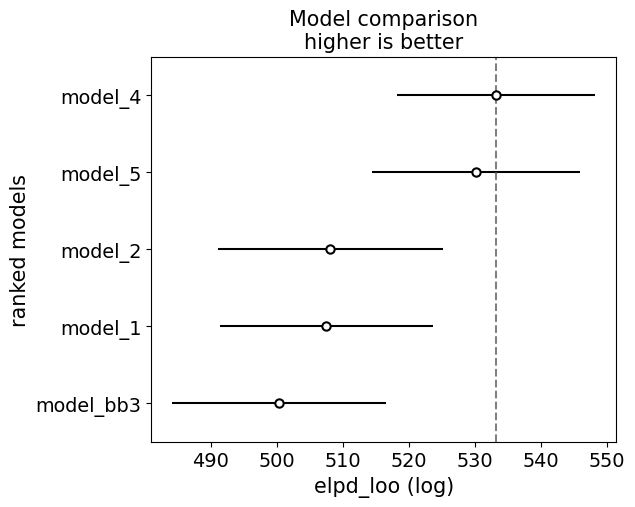

In [24]:
models = {"model_1": idata_bb1, "model_2": idata_bb2, "model_bb3": idata_bb3, "model_4": idata_bb4, "model_5": idata_bb5}
df_compare = az.compare(models)
print(df_compare)

az.plot_compare(df_compare, insample_dev=False)

**Task11**:

Which model is "better" according to this metric?

Why do you think that is?

I think that model 4 is better because it has a more positive elpd_loo which means that it is a "better" fit.

**Task12:**

The body data set has a measure of body fat percentage (siri), as well as several other measurments of other parts of a person's body, plus their age.

Create a sensible causal diagram for this set of variables.

Based on your causal diagram, which variable should you try to predict? Why?

In [17]:
body = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/body_fat.csv')

In [18]:
body.head()

,siri,age,weight,height,abdomen,thigh,wrist
0,12.3,23,70.1,172,85.2,59.0,17.1
1,6.1,22,78.8,184,83.0,58.7,18.2
2,25.3,22,70.0,168,87.9,59.6,16.6
3,10.4,26,84.0,184,86.4,60.1,18.2
4,28.7,24,83.8,181,100.0,63.2,17.7


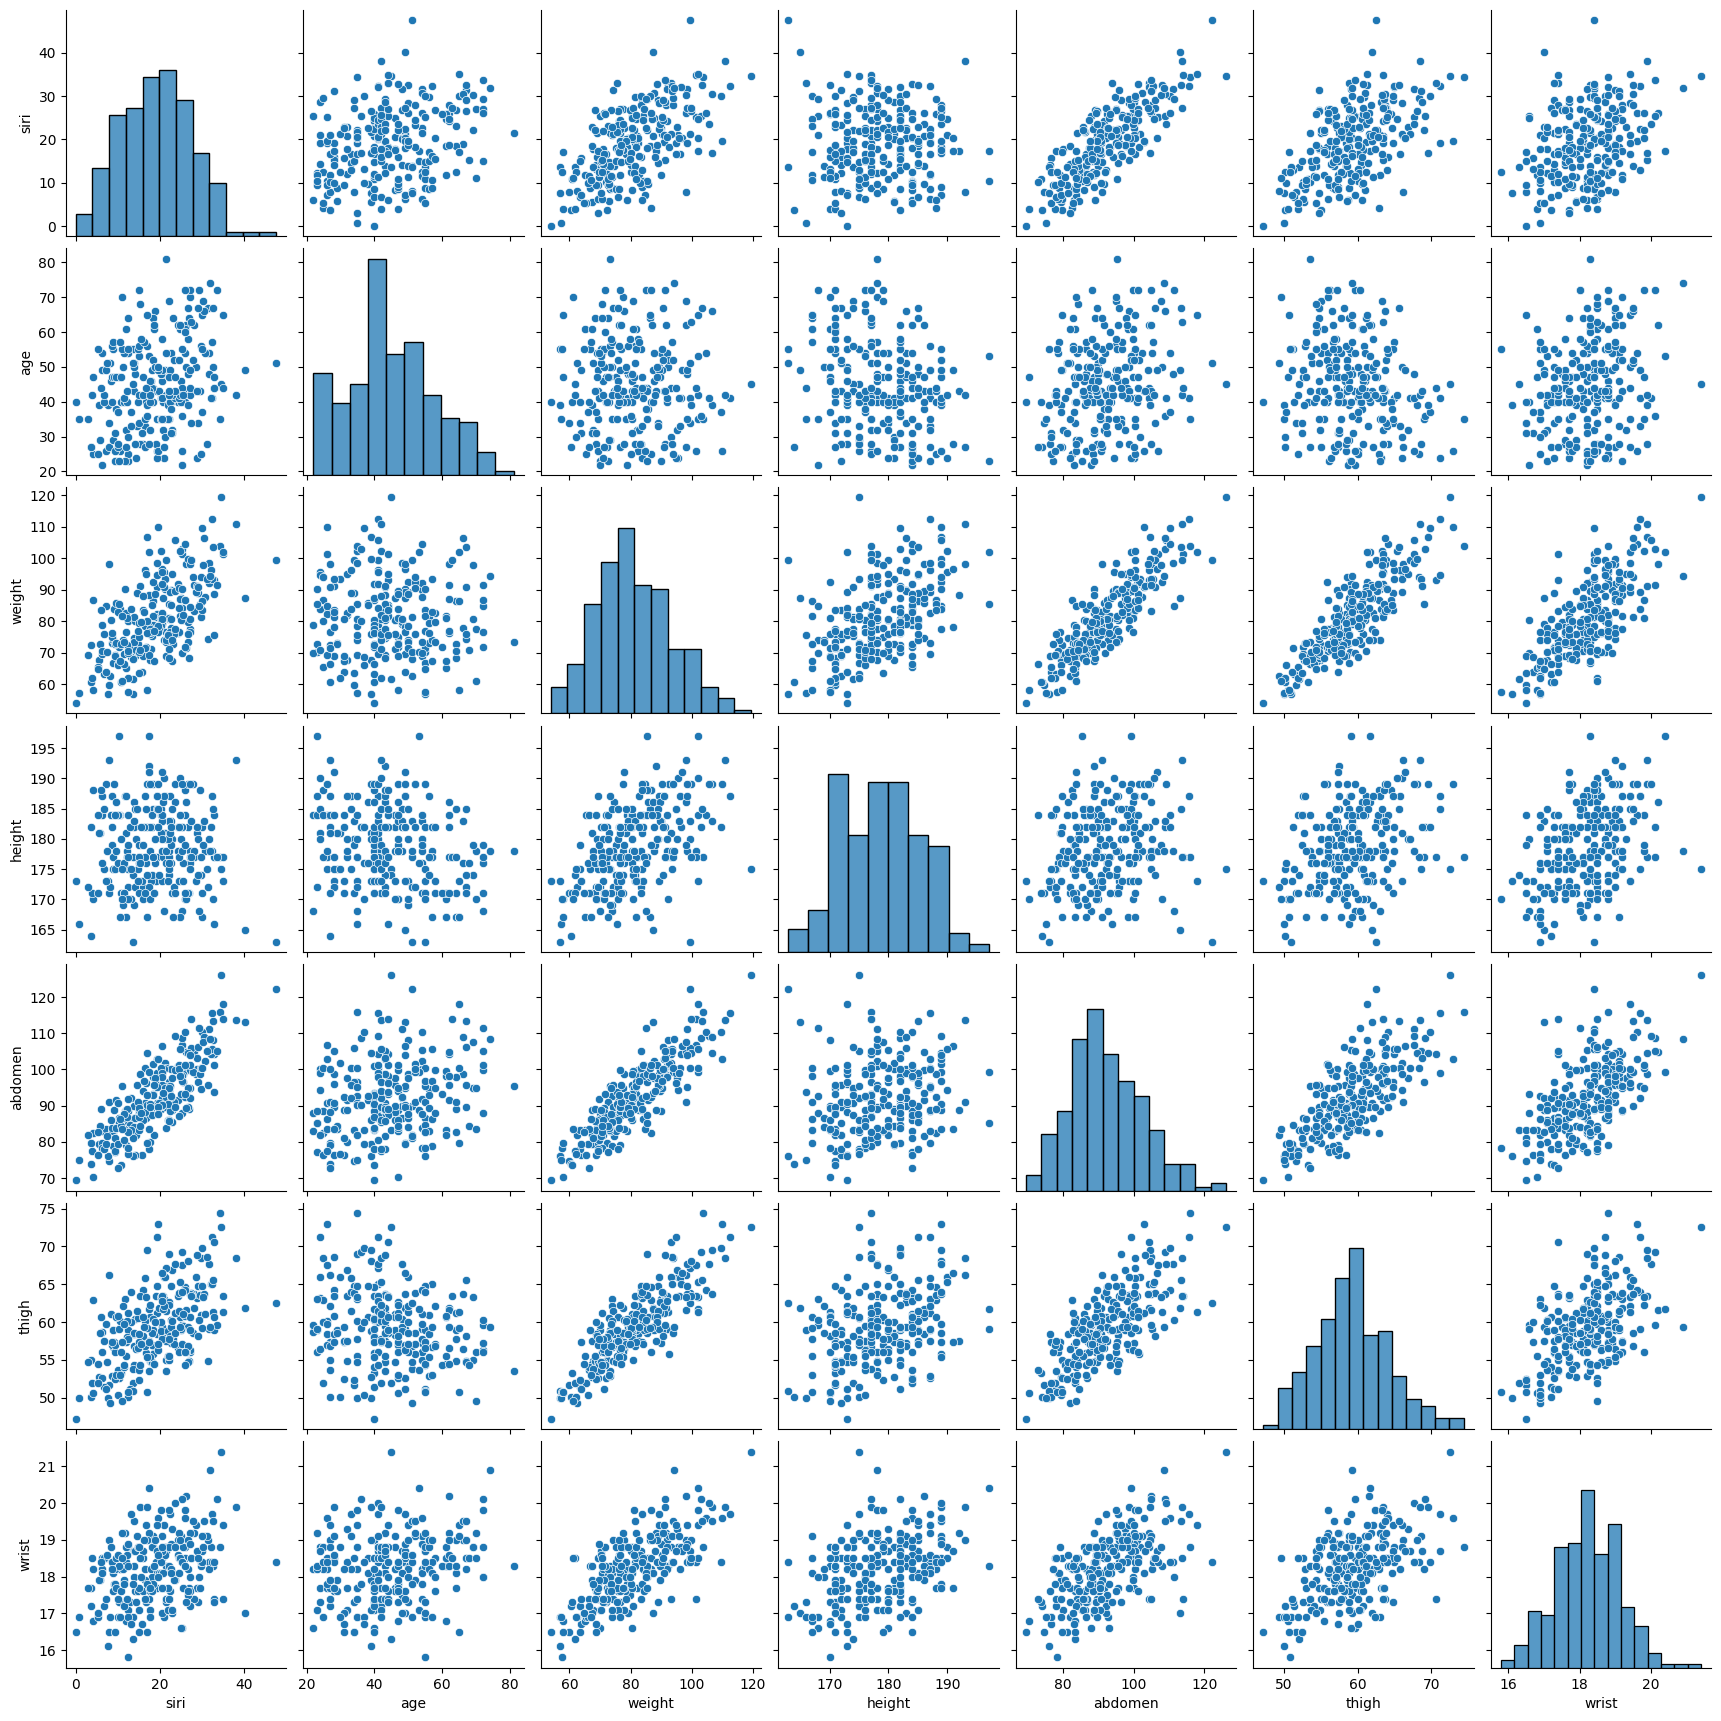

In [19]:
sns.pairplot(body)

By looking at the linear relationships, it looks like height doesn't seem to have a strong relationship (pretty scattered)

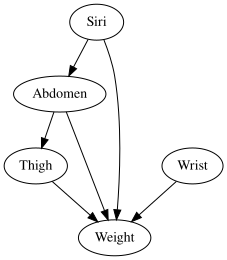

In [25]:
dag_weight = gv.Digraph()

dag_weight.node('A', 'Siri')
dag_weight.node('B', 'Abdomen')
dag_weight.node('C','Thigh')
dag_weight.node('D','Wrist')
dag_weight.node('E', 'Weight')

dag_weight.edges(['AB','BC','BE', 'CE', 'DE', 'AE'])

dag_weight

It seems that it the prediction is weight because all of the others have relations with it. There is also siri (which is just an equation for body fat %) and abdomen that have a strong relation.